In [1]:
import pandas as pd

df = pd.read_csv("../data/student_stress_dataset.csv")

df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [2]:
df.shape

(1100, 21)

In [3]:
df.isnull().sum()

anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache                        0
blood_pressure                  0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
academic_performance            0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
dtype: int64

In [4]:
df["stress_level"].value_counts()

stress_level
0    373
2    369
1    358
Name: count, dtype: int64

Dataset Shape: (1100, 21)
   anxiety_level  self_esteem  mental_health_history  depression  headache  \
0             14           20                      0          11         2   
1             15            8                      1          15         5   
2             12           18                      1          14         2   
3             16           12                      1          15         4   
4             16           28                      0           7         2   

   blood_pressure  sleep_quality  breathing_problem  noise_level  \
0               1              2                  4            2   
1               3              1                  4            3   
2               1              2                  2            2   
3               3              1                  3            4   
4               3              5                  1            3   

   living_conditions  ...  basic_needs  academic_performance  study_load  \
0                  3

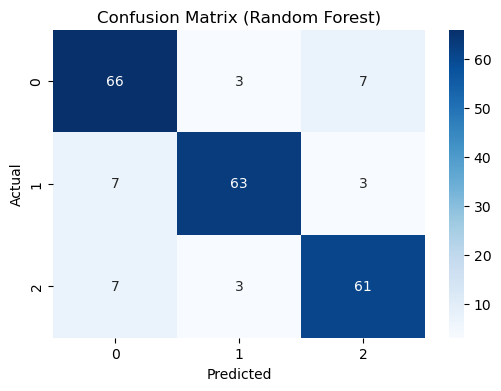

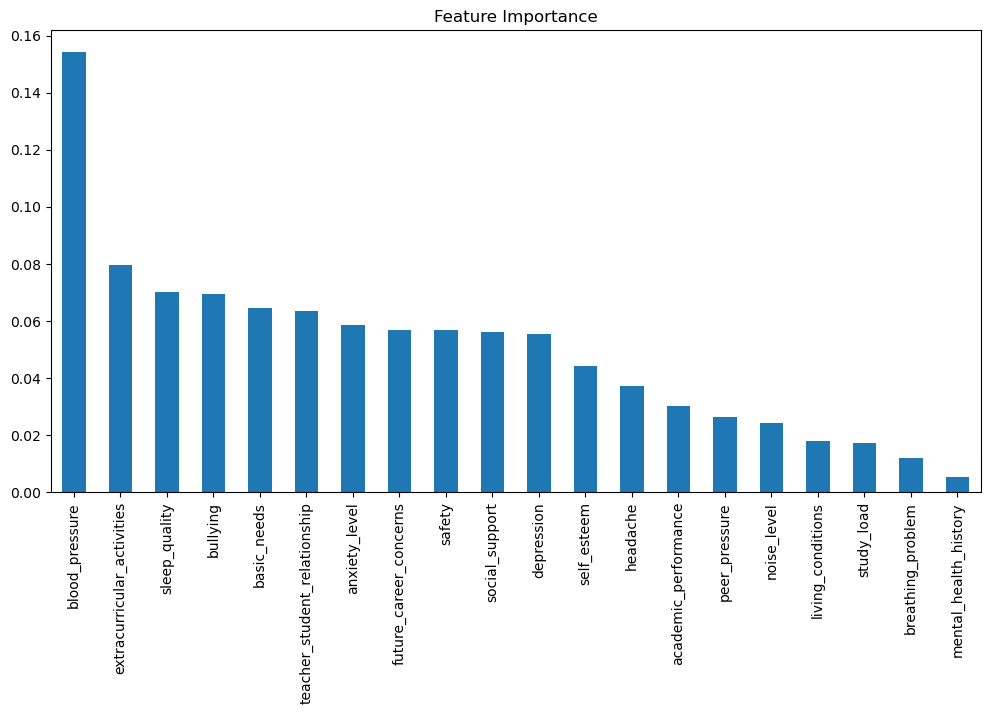


Logistic Regression selected as final model

Model saved successfully


In [1]:
# =========================
# EduMind Burnout Prediction
# Model Training Pipeline
# =========================

# 1️⃣ Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib


# 2️⃣ Load dataset
df = pd.read_csv("../data/student_stress_dataset.csv")

print("Dataset Shape:", df.shape)
print(df.head())


# 3️⃣ Separate features and target
X = df.drop("stress_level", axis=1)
y = df["stress_level"]


# 4️⃣ Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


# =========================
# MODEL 1 — Logistic Regression
# =========================

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, y_pred_log)

print("\nLogistic Regression Accuracy:", log_accuracy)
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_log))


# =========================
# MODEL 2 — Random Forest
# =========================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("\nRandom Forest Accuracy:", rf_accuracy)
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))


# =========================
# Confusion Matrix
# =========================

plt.figure(figsize=(6,4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    cmap="Blues"
)

plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# =========================
# Feature Importance
# =========================

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

plt.figure(figsize=(12,6))
importance.sort_values(ascending=False).plot(kind="bar")

plt.title("Feature Importance")
plt.show()


# =========================
# Choose Best Model
# =========================

if rf_accuracy > log_accuracy:
    best_model = rf_model
    print("\nRandom Forest selected as final model")
else:
    best_model = log_model
    print("\nLogistic Regression selected as final model")


# =========================
# Save Model
# =========================

joblib.dump(best_model, "../model.pkl")

# save column order
joblib.dump(X.columns.tolist(), "../feature_columns.pkl")

print("\nModel saved successfully")